In [1]:
import sys
sys.path.append("../src")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from portfolio import (equal_weight, naive_mean_variance, ledoit_wolf_mean_variance,
                       resampled_mean_variance, black_litterman_no_views, black_litterman_momentum)
from backtest import run_backtest, performance_summary

returns = pd.read_csv("../data/monthly_returns.csv", index_col=0, parse_dates=True)
rf = pd.read_csv("../data/rf_monthly.csv", index_col=0, parse_dates=True).squeeze("columns")

strategies = {
    "equal_weight": equal_weight,
    "naive_mv": naive_mean_variance,
    "ledoit_wolf_mv": ledoit_wolf_mean_variance,
    "resampled_mv": resampled_mean_variance,
    "bl_no_views": black_litterman_no_views,
    "bl_momentum": black_litterman_momentum,
}

all_results = {}
for name, strategy in strategies.items():
    start = time.time()
    all_results[name] = run_backtest(strategy, returns, rf)
    print(f"{name}: done in {time.time() - start:.0f}s")

summary = pd.DataFrame({name: performance_summary(*res) for name, res in all_results.items()}).T
summary.round(3)

equal_weight: done in 0s
naive_mv: done in 1s
ledoit_wolf_mv: done in 1s
resampled_mv: done in 117s
bl_no_views: done in 1s
bl_momentum: done in 1s


,ann_return,ann_vol,sharpe,max_drawdown,avg_monthly_turnover,avg_effective_n
equal_weight,0.055,0.086,0.472,-0.190,0.022,10.000
naive_mv,0.063,0.133,0.401,-0.266,0.241,1.552
ledoit_wolf_mv,0.062,0.133,0.397,-0.262,0.240,1.563
resampled_mv,0.076,0.107,0.586,-0.204,0.143,2.916
bl_no_views,0.070,0.091,0.605,-0.211,0.020,7.342
bl_momentum,0.071,0.095,0.595,-0.201,0.331,5.008


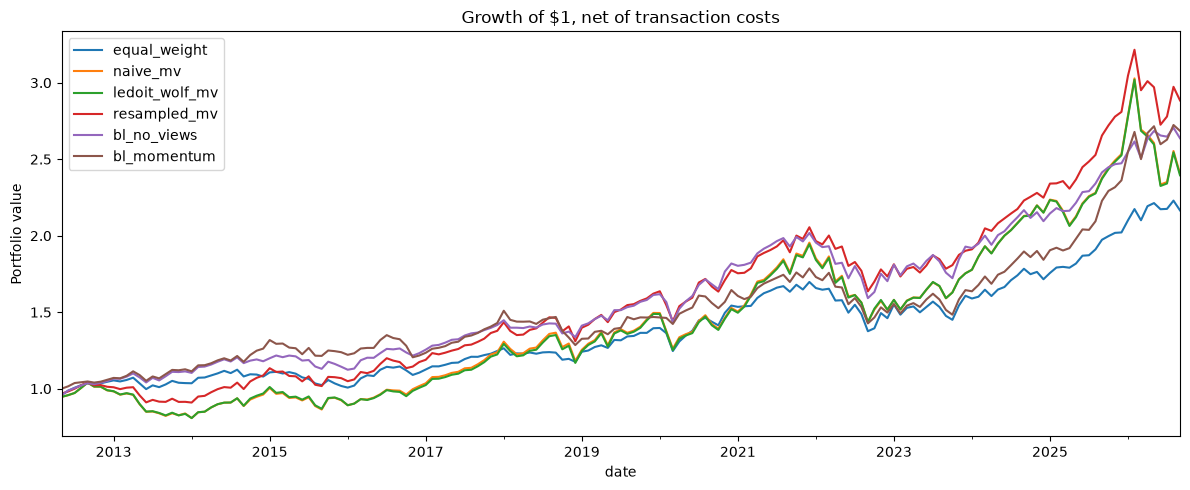

In [2]:
wealth = pd.DataFrame({name: (1 + res[0]["net"]).cumprod() for name, res in all_results.items()})

wealth.plot(figsize=(12, 5), title="Growth of $1, net of transaction costs")
plt.ylabel("Portfolio value")
plt.tight_layout()
plt.show()

In [3]:
net_returns = pd.DataFrame({name: res[0]["net"] for name, res in all_results.items()})
net_returns["rf"] = rf.reindex(net_returns.index)
net_returns.to_csv("../data/backtest_net_returns.csv")
print(f"Saved {len(net_returns)} months x {net_returns.shape[1]} columns")

Saved 173 months x 7 columns
